In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sumona2samia/skinburndataset/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_rotate_45_augmented_flip_horizontal_img153_jpg.rf.d6c9a2cfc14449739cfa3c7dc44ca885.jpg
/kaggle/input/datasets/sumona2samia/skinburndataset/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_augmented_flip_horizontal_img360_jpg.rf.1174acba2e2bfffbbfa4c1cd63009ba3.jpg
/kaggle/input/datasets/sumona2samia/skinburndataset/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_augmented_flip_horizontal_img476.jpg
/kaggle/input/datasets/sumona2samia/skinburndataset/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_brightness_1.5_img819_jpg.rf.a56ae5f661f572775d4e3ec9859633a6.jpg
/kaggle/input/datasets/sumona2samia/skinburndataset/dataset_split/valid/Second Degree Burn Partial of Intermediate Thickness/augmented_flip_horizontal_img1241_jpg.

In [2]:
import os

print(os.listdir("/kaggle/input"))

['datasets', 'notebooks']


In [3]:
for dataset in os.listdir("/kaggle/input"):
    print(dataset)
    print(os.listdir(f"/kaggle/input/{dataset}"))

datasets
['sumona2samia']
notebooks
['sumona2samia']


Datapath

In [4]:
DATASET_ROOT = "/kaggle/input/datasets/sumona2samia/skinburndataset/dataset_split"

TRAIN_PATH = DATASET_ROOT + "/train"
VAL_PATH   = DATASET_ROOT + "/valid"
TEST_PATH  = DATASET_ROOT + "/test"

In [5]:
import os

print(os.listdir("/kaggle/input/datasets/sumona2samia/skinburndataset/dataset_split"))

['valid', 'test', 'train']


In [6]:
import os

print(os.listdir(TRAIN_PATH))

['Second Degree Burn Partial of Intermediate Thickness', 'Third Degree Burn Full hickness', 'First Degree Burn Superficial Thickness', 'No Sunburn']


Random Image

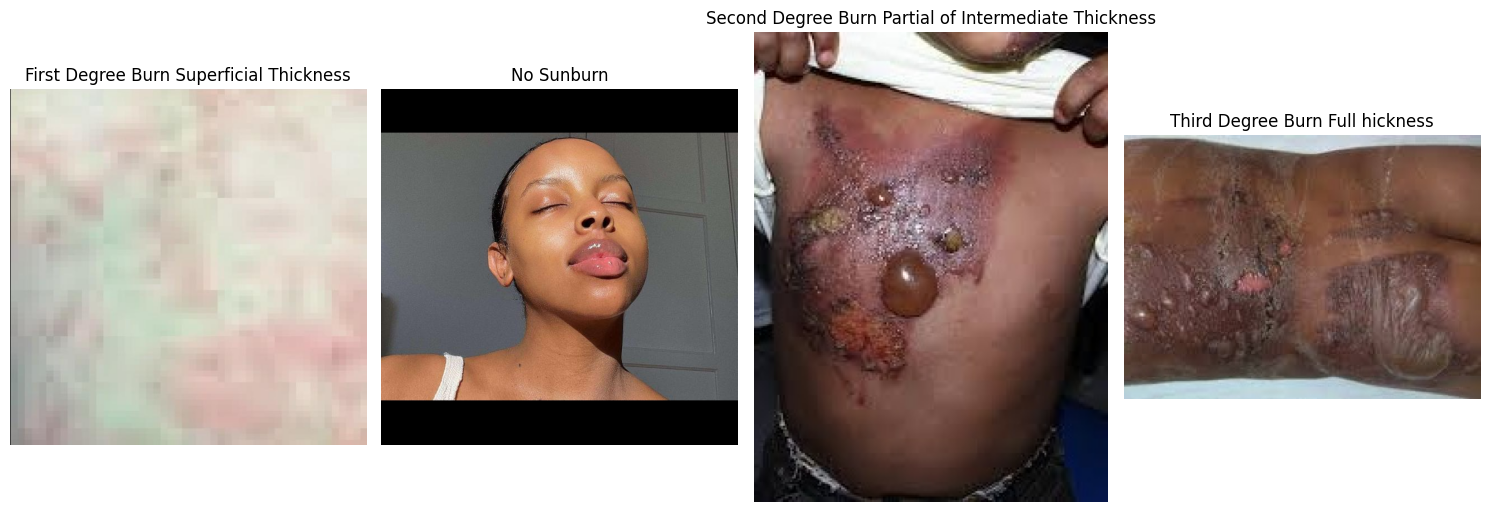

In [7]:
import os
import cv2
import matplotlib.pyplot as plt
import random

def show_one_image_per_class(train_path):
    class_names = sorted(os.listdir(train_path))

    plt.figure(figsize=(15, 5))

    for i, class_name in enumerate(class_names):
        class_folder = os.path.join(train_path, class_name)

        if not os.path.isdir(class_folder):
            continue

        images = []
        for file in os.listdir(class_folder):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images.append(os.path.join(class_folder, file))

        if len(images) == 0:
            continue

        img_path = random.choice(images)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(class_names), i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_one_image_per_class(TRAIN_PATH)

Resized Image

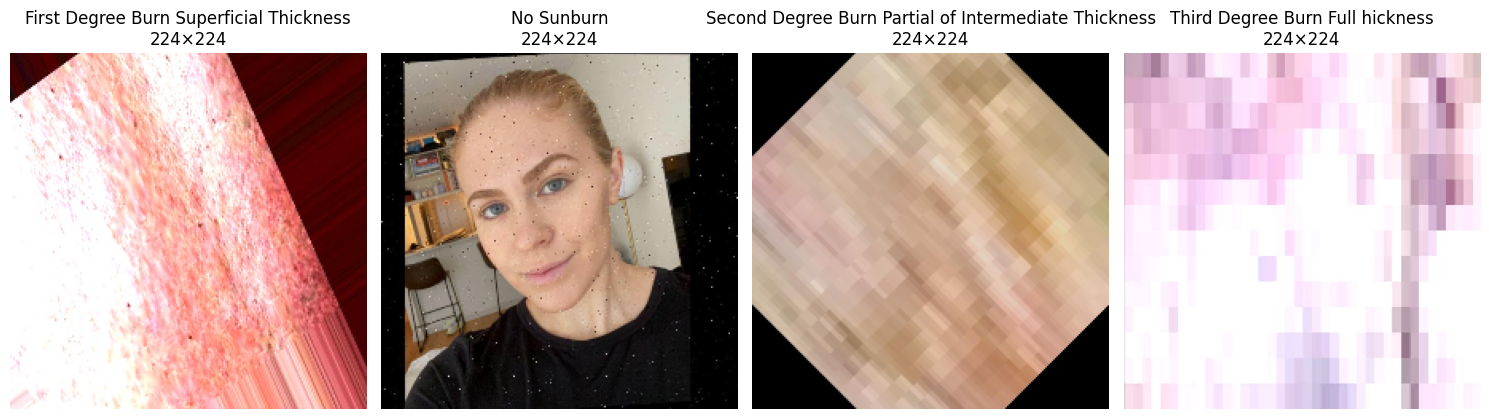

In [8]:
import os
import cv2
import matplotlib.pyplot as plt
import random

def show_one_image_per_class(train_path):
    class_names = sorted(os.listdir(train_path))

    plt.figure(figsize=(15, 5))

    for i, class_name in enumerate(class_names):
        class_folder = os.path.join(train_path, class_name)

        if not os.path.isdir(class_folder):
            continue

        images = []
        for file in os.listdir(class_folder):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images.append(os.path.join(class_folder, file))

        if len(images) == 0:
            continue

        img_path = random.choice(images)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ✅ RESIZE TO 224x224
        img = cv2.resize(img, (224, 224))

        plt.subplot(1, len(class_names), i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
        plt.title(f"{class_name}\n224×224")

    plt.tight_layout()
    plt.show()

show_one_image_per_class(TRAIN_PATH)

Skin Segmentation

Total images: 10817


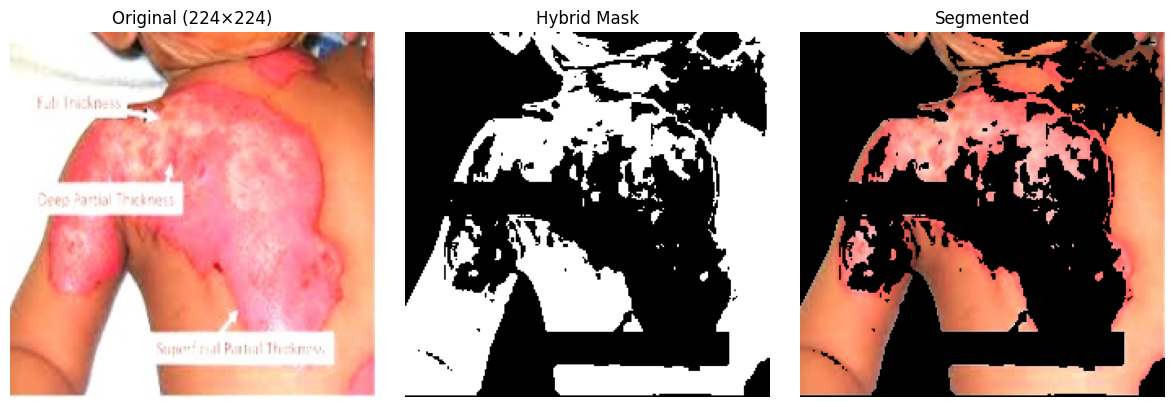

In [9]:
def hybrid_skin_mask(image):
    img = image.astype(np.float32)

    # RGB
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]

    rgb_mask = (
        (R > 95) &
        (G > 40) &
        (B > 20) &
        ((np.max(img, axis=2) - np.min(img, axis=2)) > 15) &
        (np.abs(R - G) > 15) &
        (R > G) &
        (R > B)
    )

    rgb_mask = rgb_mask.astype(np.uint8)

    # HSV
    hsv = cv2.cvtColor(image.astype(np.uint8), cv2.COLOR_RGB2HSV)
    H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

    hsv_mask = (
        (H >= 0) & (H <= 50) &
        (S >= 0.23 * 255) & (S <= 0.68 * 255) &
        (V >= 0.35 * 255)
    )

    hsv_mask = hsv_mask.astype(np.uint8)

    # Combine
    final_mask = cv2.bitwise_and(rgb_mask, hsv_mask)

    return final_mask * 255

# Run ONCE
ALL_IMAGES = []

for root, _, files in os.walk(TRAIN_PATH):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            ALL_IMAGES.append(os.path.join(root, file))

print("Total images:", len(ALL_IMAGES))


def get_random_image_fast():
    return random.choice(ALL_IMAGES)

def show_hybrid_segmentation(image_path):
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    img = cv2.resize(img, (224, 224))   # faster first
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = hybrid_skin_mask(img)
    segmented = cv2.bitwise_and(img, img, mask=mask)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original (224×224)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Hybrid Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(segmented)
    plt.title("Segmented")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

img_path = get_random_image_fast()
show_hybrid_segmentation(img_path)

Burn Segmentation

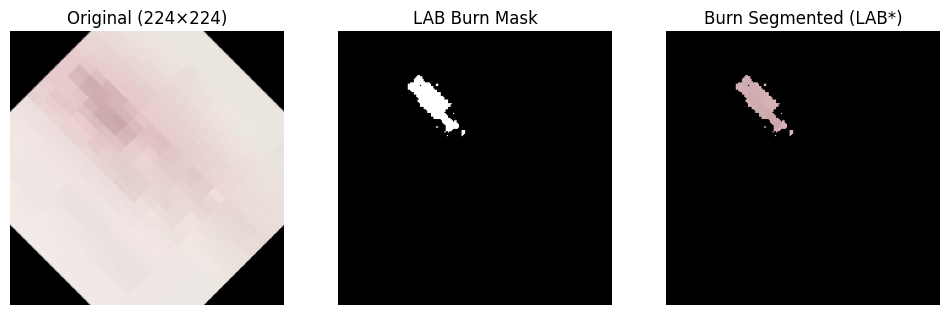

In [10]:
import cv2
import numpy as np

def lab_burn_mask(image):
    # Convert RGB → LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0]
    A = lab[:, :, 1]
    B = lab[:, :, 2]

    # Normalize (optional but improves stability)
    L = L / 255.0
    A = A / 255.0
    B = B / 255.0

    # -----------------------------
    # BURN RULE (heuristic)
    # -----------------------------
    burn_mask = (
        (A > 0.55) &      # strong redness
        (L > 0.2) & (L < 0.85)  # avoid extreme dark/light regions
    )

    return (burn_mask.astype(np.uint8) * 255)

import os, random

def get_random_image(path):
    imgs = []
    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(('.jpg','.png','.jpeg')):
                imgs.append(os.path.join(root, f))
    return random.choice(imgs)

import matplotlib.pyplot as plt

def show_lab_burn_segmentation(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    mask = lab_burn_mask(img)

    segmented = cv2.bitwise_and(img, img, mask=mask)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original (224×224)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("LAB Burn Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(segmented)
    plt.title("Burn Segmented (LAB*)")
    plt.axis("off")

    plt.show()

img_path = get_random_image(TRAIN_PATH)
show_lab_burn_segmentation(img_path)

Final Segmentation

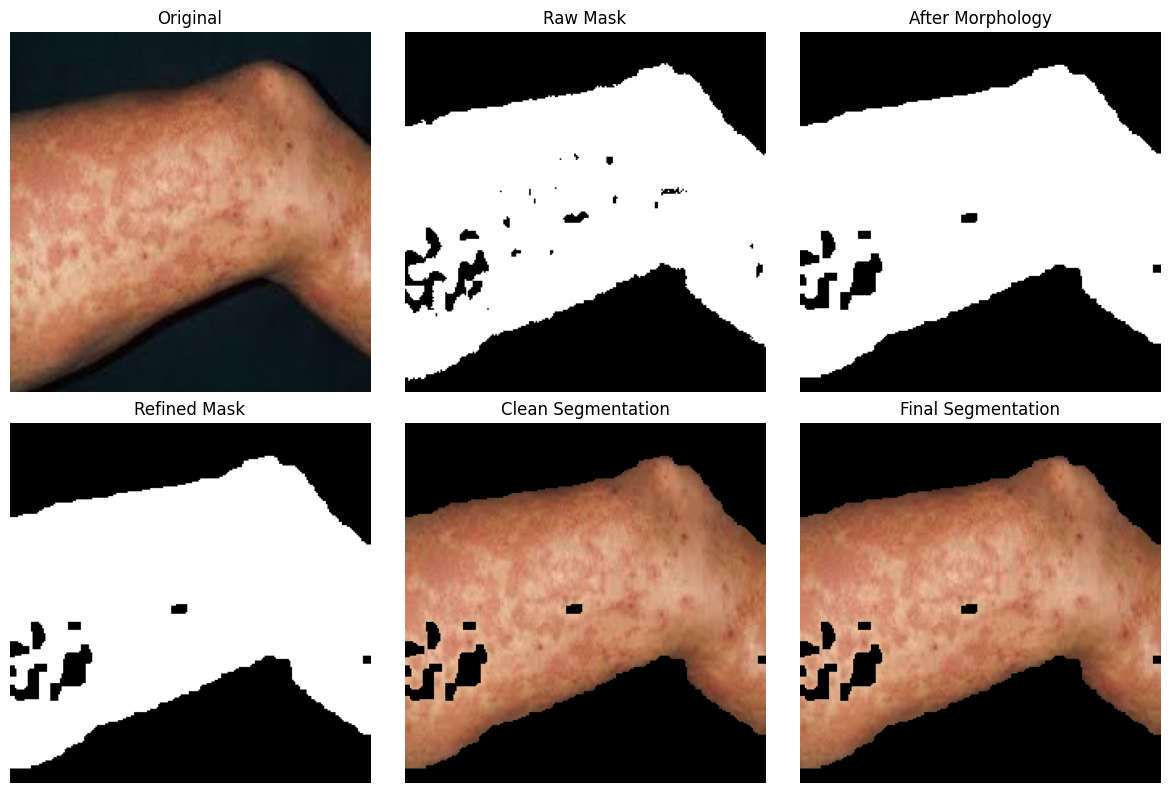

In [11]:
def get_random_image(path):
    imgs = []

    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                imgs.append(os.path.join(root, f))

    return random.choice(imgs)

def lab_burn_mask(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0] / 255.0
    A = lab[:, :, 1] / 255.0

    mask = (
        (A > 0.55) &
        (L > 0.2) & (L < 0.85)
    )

    return (mask.astype(np.uint8) * 255)

def post_process_mask(mask):
    kernel = np.ones((5,5), np.uint8)

    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, 1)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, 2)

    return closed

def refine_mask(mask):
    kernel = np.ones((3,3), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    return mask

def show_pipeline(train_path):

    img_path = get_random_image(train_path)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Step 1: LAB mask
    raw_mask = lab_burn_mask(img)

    # Step 2: Morphology
    clean_mask = post_process_mask(raw_mask)

    # Step 3: Refinement
    refined_mask = refine_mask(clean_mask)

    # Step 4: Segmentation
    raw_seg = cv2.bitwise_and(img, img, mask=raw_mask)
    clean_seg = cv2.bitwise_and(img, img, mask=clean_mask)
    final_seg = cv2.bitwise_and(img, img, mask=refined_mask)

    # Step 5: Plot
    plt.figure(figsize=(12,8))

    plt.subplot(2,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,3,2)
    plt.imshow(raw_mask, cmap="gray")
    plt.title("Raw Mask")
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("After Morphology")
    plt.axis("off")

    plt.subplot(2,3,4)
    plt.imshow(refined_mask, cmap="gray")
    plt.title("Refined Mask")
    plt.axis("off")

    plt.subplot(2,3,5)
    plt.imshow(clean_seg)
    plt.title("Clean Segmentation")
    plt.axis("off")

    plt.subplot(2,3,6)
    plt.imshow(final_seg)
    plt.title("Final Segmentation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_pipeline(TRAIN_PATH)

Extracted Region

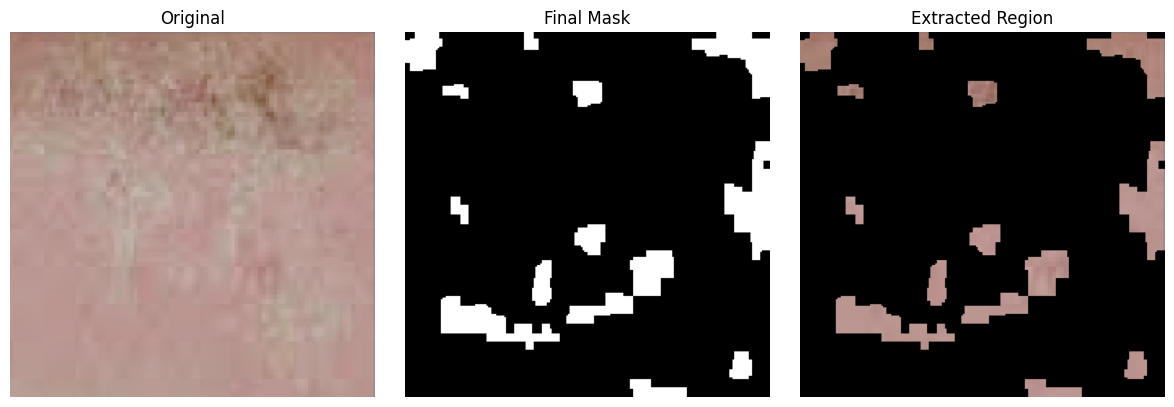

In [12]:
def extract_region(image, mask):
    # ensure mask is binary
    mask = (mask > 0).astype(np.uint8) * 255

    # extract region
    extracted = cv2.bitwise_and(image, image, mask=mask)

    return extracted

def show_region_extraction(train_path):
    img_path = get_random_image(train_path)

    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Step 1: LAB mask
    raw_mask = lab_burn_mask(img)

    # Step 2: Morphology
    clean_mask = post_process_mask(raw_mask)

    # Step 3: Region extraction
    extracted = extract_region(img, clean_mask)

    # Plot
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("Final Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(extracted)
    plt.title("Extracted Region")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
show_region_extraction(TRAIN_PATH)


3-Channel Region

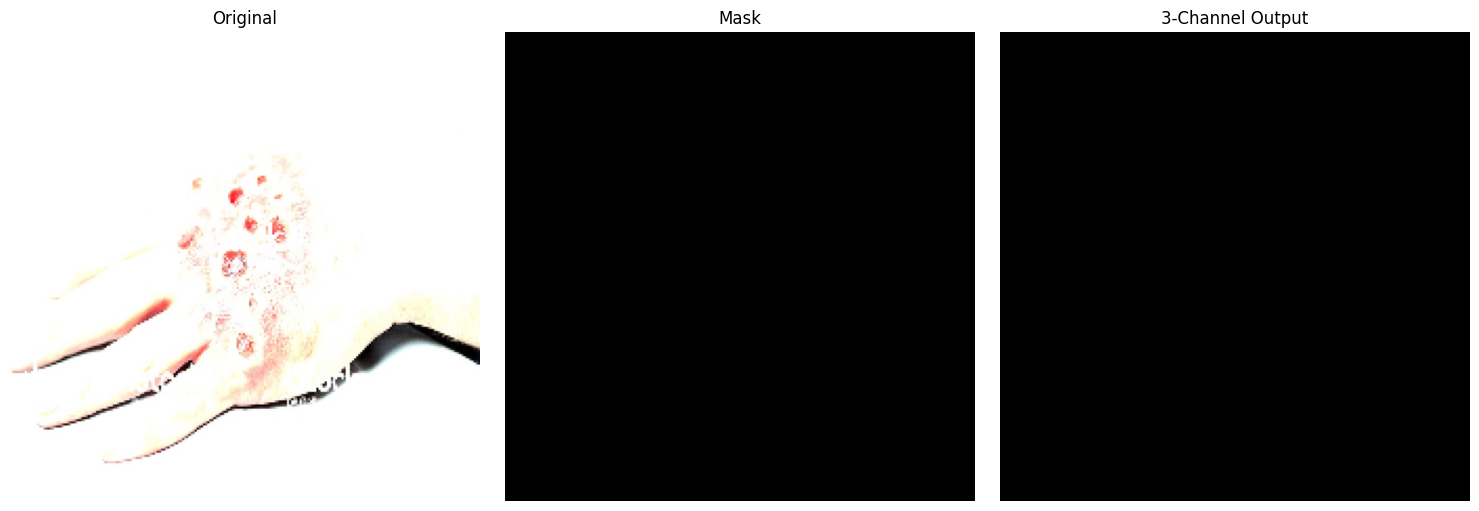

In [13]:
import cv2
import numpy as np

def extract_3channel_region(image, mask):
    # ensure binary mask
    mask = (mask > 0).astype(np.uint8)

    # expand mask to 3 channels
    mask_3ch = np.stack([mask, mask, mask], axis=-1)

    # apply mask
    output = image * mask_3ch

    return output

import matplotlib.pyplot as plt

def show_3channel_pipeline(train_path):
    img_path = get_random_image(train_path)

    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # LAB segmentation
    raw_mask = lab_burn_mask(img)

    # Morphology cleanup
    clean_mask = post_process_mask(raw_mask)

    # 3-channel output
    extracted_3ch = extract_3channel_region(img, clean_mask)

    # Visualization
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(extracted_3ch)
    plt.title("3-Channel Output")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_3channel_pipeline(TRAIN_PATH)

Train Model

In [14]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [16]:
LR = 1e-4
EPOCHS = 100
BATCH_SIZE = 32
MODEL_SAVE_PATH = "/kaggle/working/vgg19_best.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 4 

In [17]:
model = models.vgg19(pretrained=True)

# Modify classifier
model.classifier[6] = nn.Linear(4096, num_classes)

# Partial fine-tuning (BEST PRACTICE)
for param in model.features[:28].parameters():
    param.requires_grad = False

for param in model.features[28:].parameters():
    param.requires_grad = True

model = model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 190MB/s]


In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=10,
    factor=0.5
)

In [19]:
def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, device, epochs):

    best_val_loss = float('inf')
    patience = 10
    counter = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):

        # ===== TRAIN =====
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader)
        train_acc = correct / total

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        scheduler.step(val_loss)

        # ===== SAVE BEST MODEL =====
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
        else:
            counter += 1

        # Store history
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print("-" * 40)

        # ===== EARLY STOPPING =====
        if counter >= patience:
            print("Early stopping triggered")
            break

    # ===== LOAD BEST MODEL SAFELY =====
    if os.path.exists(MODEL_SAVE_PATH):
        model.load_state_dict(torch.load(MODEL_SAVE_PATH))

    model = model.to(device)
    model.eval()

    return model, train_losses, val_losses, train_accs, val_accs

In [20]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=TRAIN_PATH,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=VAL_PATH,
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [21]:
model, train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    DEVICE,
    EPOCHS
)

Epoch 1/100
Train Loss: 0.5877, Train Acc: 0.7498
Val Loss: 0.4732, Val Acc: 0.8096
----------------------------------------
Epoch 2/100
Train Loss: 0.3960, Train Acc: 0.8436
Val Loss: 0.5822, Val Acc: 0.7845
----------------------------------------
Epoch 3/100
Train Loss: 0.2932, Train Acc: 0.8919
Val Loss: 0.4249, Val Acc: 0.8476
----------------------------------------
Epoch 4/100
Train Loss: 0.2255, Train Acc: 0.9163
Val Loss: 0.4020, Val Acc: 0.8523
----------------------------------------
Epoch 5/100
Train Loss: 0.1922, Train Acc: 0.9302
Val Loss: 0.4187, Val Acc: 0.8627
----------------------------------------
Epoch 6/100
Train Loss: 0.1563, Train Acc: 0.9442
Val Loss: 0.4778, Val Acc: 0.8653
----------------------------------------
Epoch 7/100
Train Loss: 0.1242, Train Acc: 0.9534
Val Loss: 0.5093, Val Acc: 0.8787
----------------------------------------
Epoch 8/100
Train Loss: 0.1059, Train Acc: 0.9618
Val Loss: 0.4884, Val Acc: 0.8696
----------------------------------------


In [22]:
print(model)  # should show VGG, not AlexNet
print(next(model.parameters()).device)  # should be cuda

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

Accuracy

In [23]:
def evaluate_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [24]:
test_dataset = datasets.ImageFolder(
    root=TEST_PATH,
    transform=val_transforms  # same as validation
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [25]:
train_acc = evaluate_model(model, train_loader, DEVICE)
val_acc   = evaluate_model(model, val_loader, DEVICE)
test_acc = evaluate_model(model, test_loader, DEVICE)

In [26]:
print("\n===== FINAL ACCURACY =====")
print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Test Accuracy       : {test_acc*100:.2f}%")


===== FINAL ACCURACY =====
Train Accuracy      : 93.78%
Validation Accuracy : 85.23%
Test Accuracy       : 84.85%


Per class accuracy

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
def get_all_preds(model, loader, device):
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)
y_pred, y_true, y_prob = get_all_preds(model, test_loader, DEVICE)

class_names = test_loader.dataset.classes
num_classes = len(class_names)
print("\n===== PER-CLASS ACCURACY =====")

for i in range(num_classes):
    idx = (y_true == i)
    acc = np.sum(y_pred[idx] == i) / np.sum(idx)
    print(f"{class_names[i]}: {acc:.4f}")


===== PER-CLASS ACCURACY =====
First Degree Burn Superficial Thickness: 0.7702
No Sunburn: 0.9797
Second Degree Burn Partial of Intermediate Thickness: 0.8092
Third Degree Burn Full hickness: 0.9278


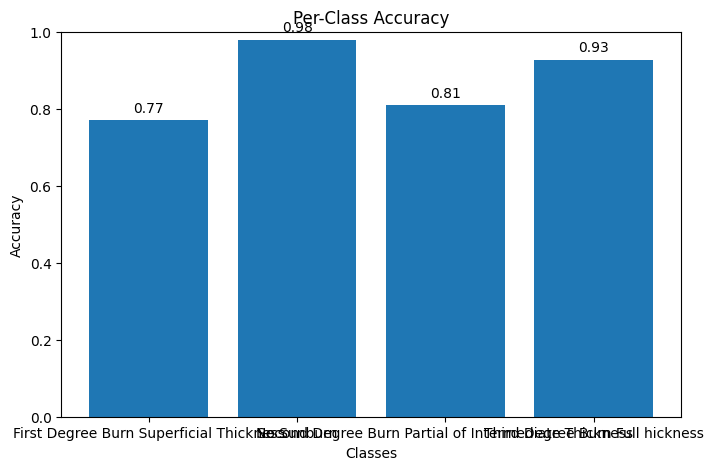

In [28]:
import numpy as np
import matplotlib.pyplot as plt

y_pred, y_true, _ = get_all_preds(model, test_loader, DEVICE)

class_names = test_loader.dataset.classes
num_classes = len(class_names)

class_acc = []

for i in range(num_classes):
    idx = (y_true == i)
    acc = np.sum(y_pred[idx] == i) / np.sum(idx)
    class_acc.append(acc)
plt.figure(figsize=(8, 5))

plt.bar(class_names, class_acc)

plt.title("Per-Class Accuracy")
plt.xlabel("Classes")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

for i, v in enumerate(class_acc):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

Confusion matrix & Normalised confusion matrix

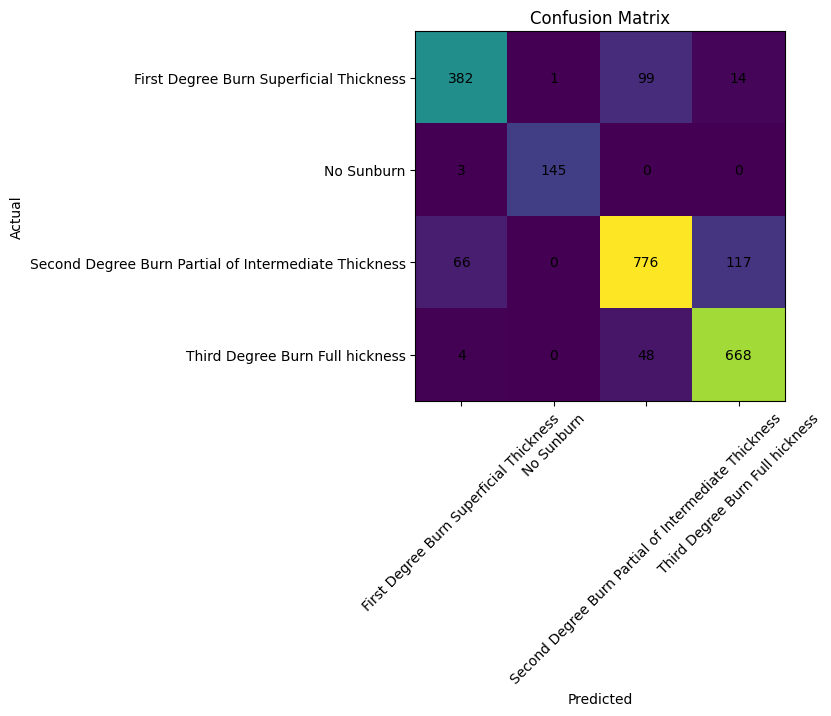

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [30]:
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_true, y_pred, target_names=class_names))


===== CLASSIFICATION REPORT =====
                                                      precision    recall  f1-score   support

             First Degree Burn Superficial Thickness       0.84      0.77      0.80       496
                                          No Sunburn       0.99      0.98      0.99       148
Second Degree Burn Partial of Intermediate Thickness       0.84      0.81      0.82       959
                     Third Degree Burn Full hickness       0.84      0.93      0.88       720

                                            accuracy                           0.85      2323
                                           macro avg       0.88      0.87      0.87      2323
                                        weighted avg       0.85      0.85      0.85      2323



In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred, y_true, _ = get_all_preds(model, test_loader, DEVICE)

class_names = test_loader.dataset.classes

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

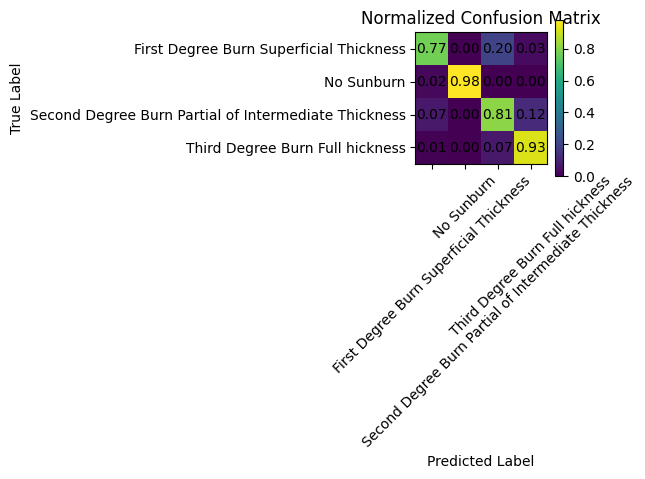

In [32]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_norm, interpolation='nearest')

plt.title("Normalized Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Add values inside boxes
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}",
                 ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.tight_layout()
plt.show()

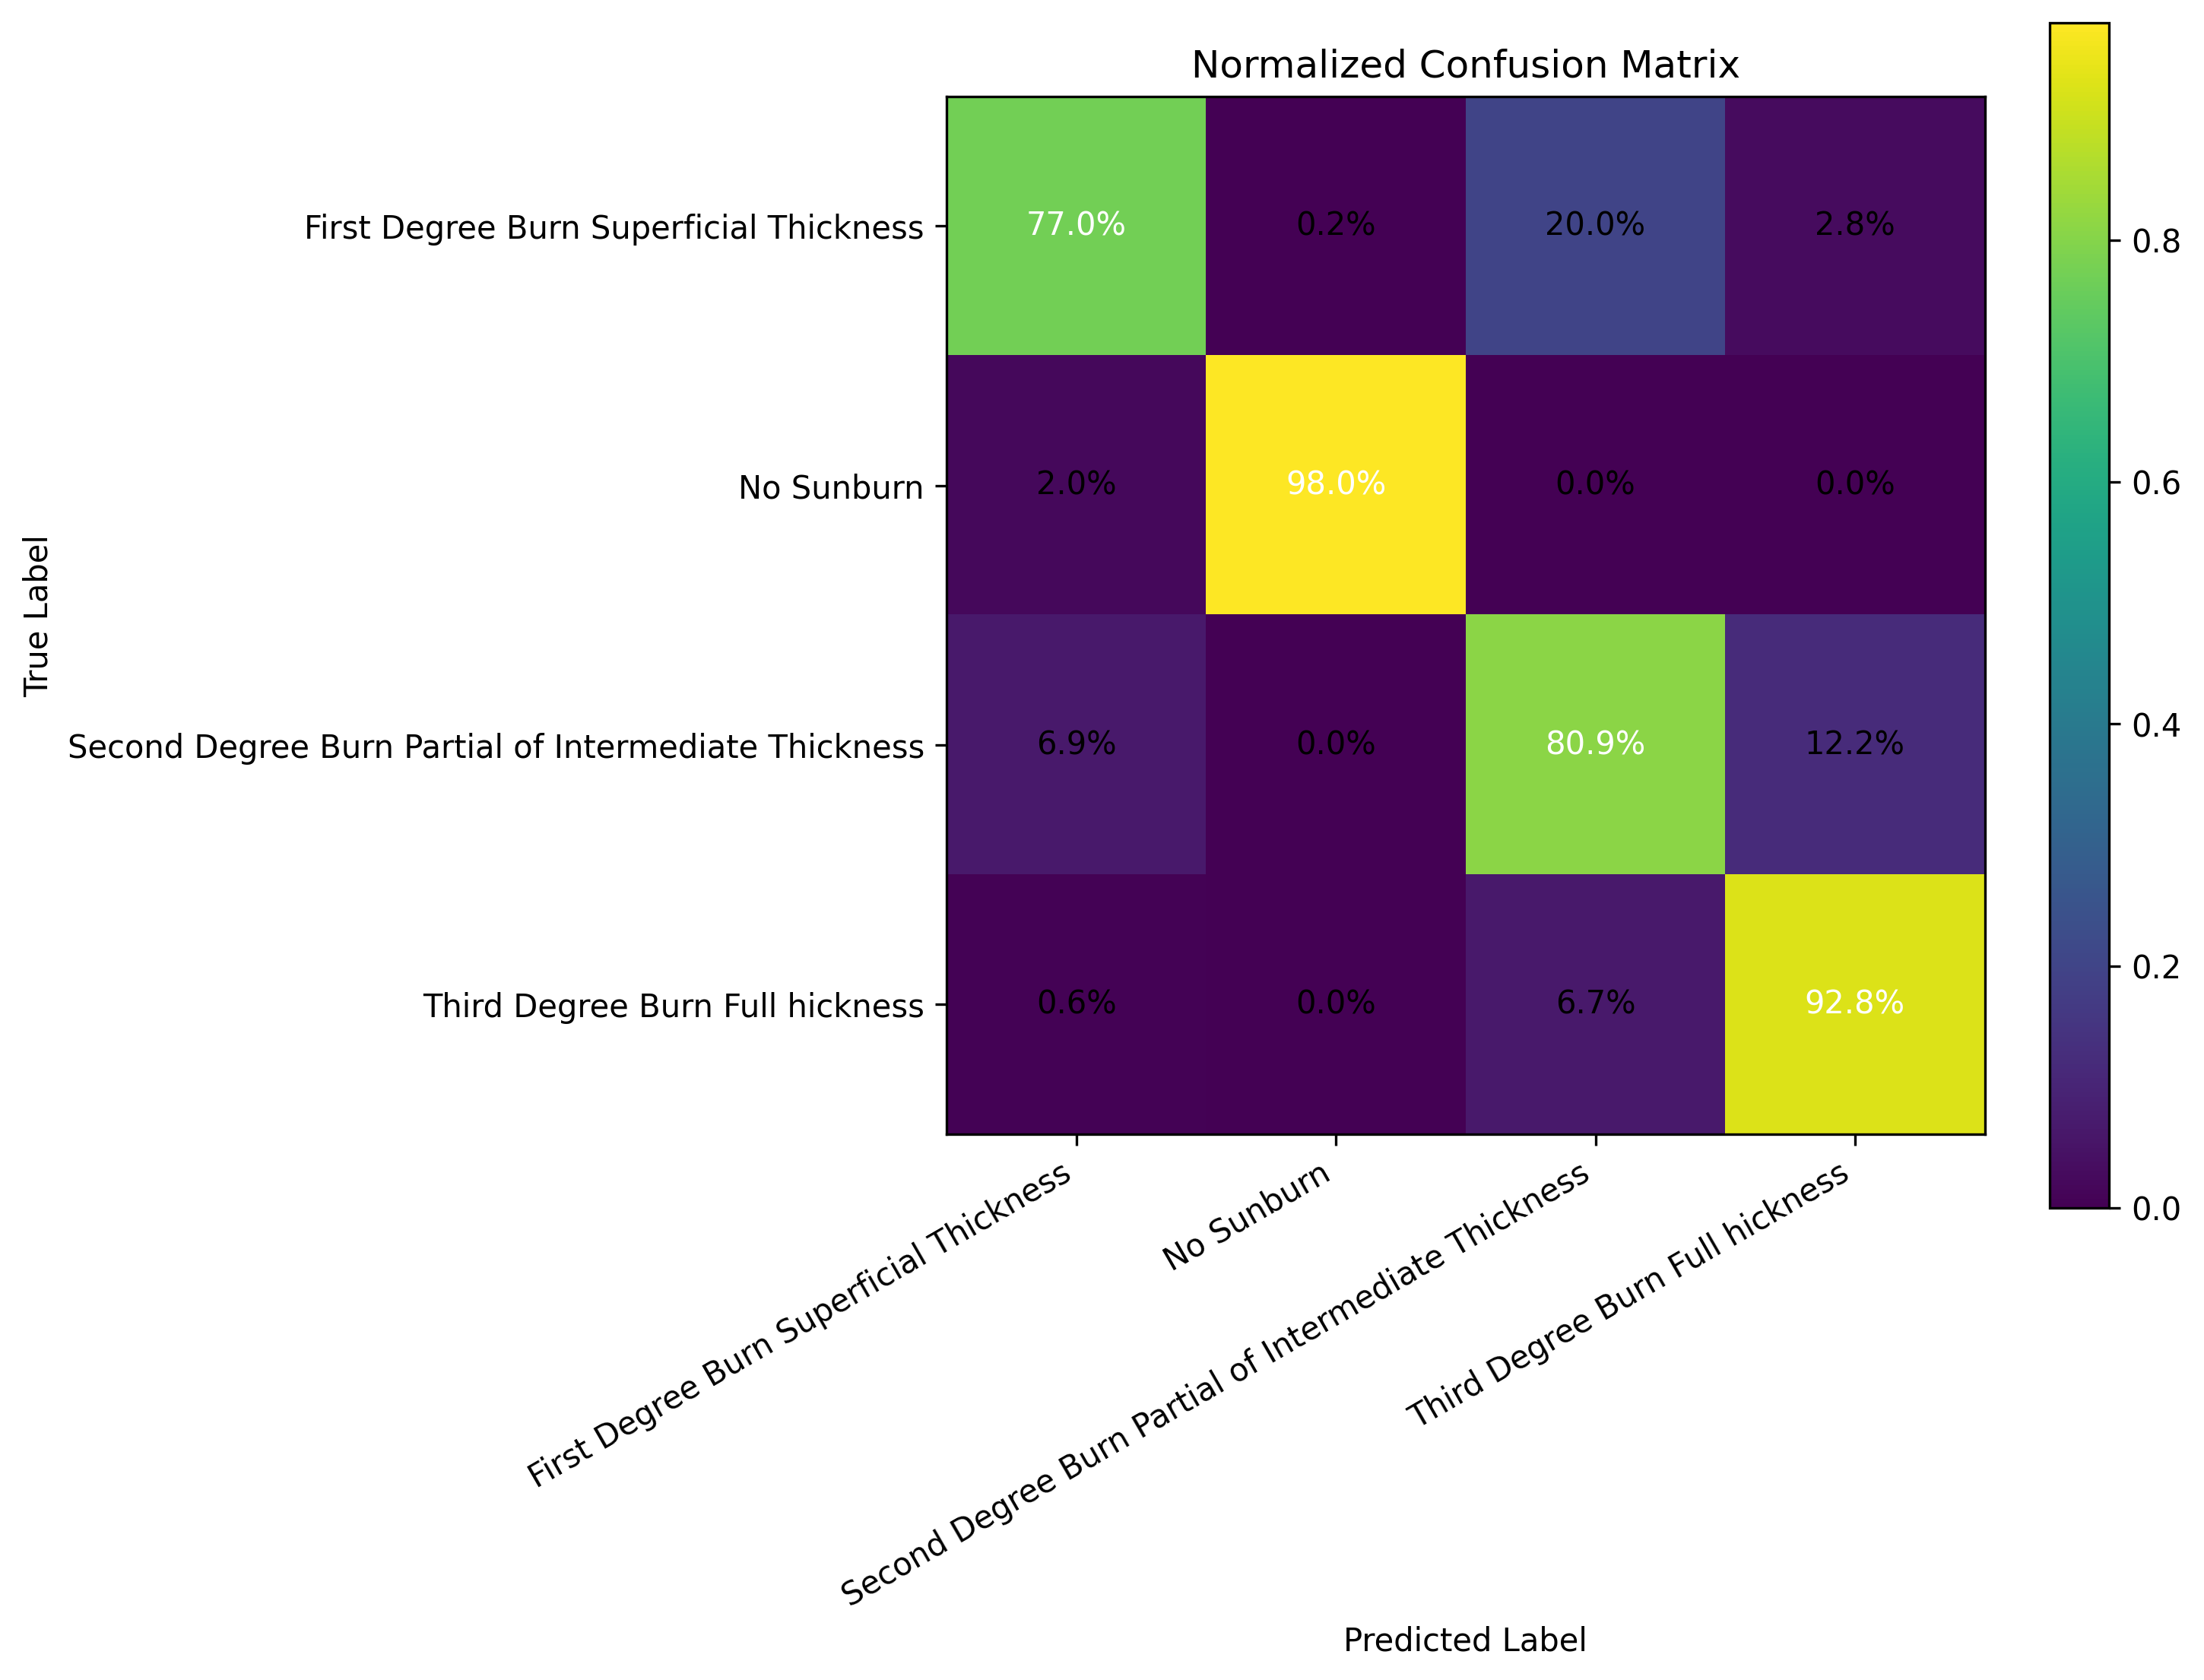

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize (row-wise)
cm_norm = np.divide(
    cm.astype(float),
    cm.sum(axis=1, keepdims=True),
    where=cm.sum(axis=1, keepdims=True) != 0
)

classes = train_dataset.classes
x = np.arange(len(classes))

plt.figure(figsize=(10,8), dpi=300)

# Plot normalized matrix
plt.imshow(cm_norm)
plt.title("Normalized Confusion Matrix")
plt.colorbar()

# Proper ticks
plt.xticks(x, classes, rotation=30, ha='right')
plt.yticks(x, classes)

# Add percentage values
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i, f"{cm_norm[i,j]*100:.1f}%",
            ha="center", va="center",
            color="white" if cm_norm[i,j] > 0.5 else "black"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("/kaggle/working/normalized_confusion_matrix.png", dpi=300)
plt.show()

Multiclass ROC

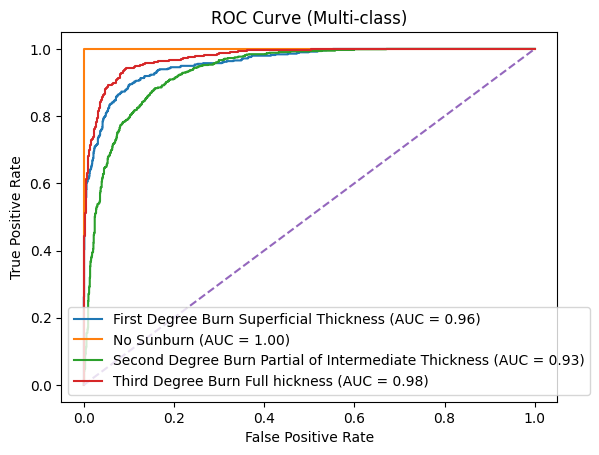

In [34]:
# Binarize labels
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()

plt.show()

Micro ROC

In [35]:
import numpy as np
from sklearn.preprocessing import label_binarize

num_classes = len(test_loader.dataset.classes)

y_true_bin = label_binarize(y_true, classes=range(num_classes))

In [36]:
from sklearn.metrics import roc_curve, auc

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

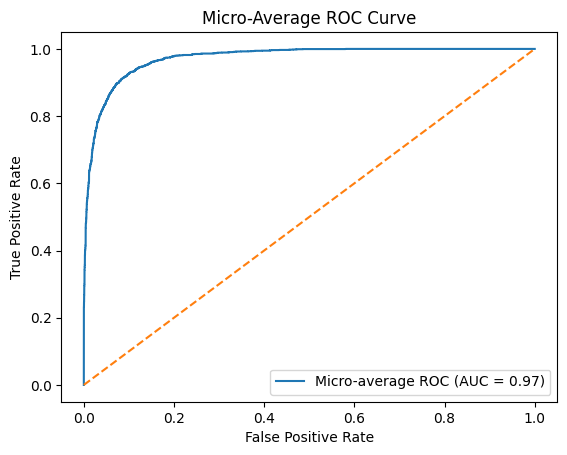

In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

num_classes = len(test_loader.dataset.classes)

y_pred, y_true, y_prob = get_all_preds(model, test_loader, DEVICE)
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# MICRO ROC
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.figure()
plt.plot(fpr_micro, tpr_micro, label=f"Micro-average ROC (AUC = {roc_auc_micro:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Micro-Average ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Macro ROC

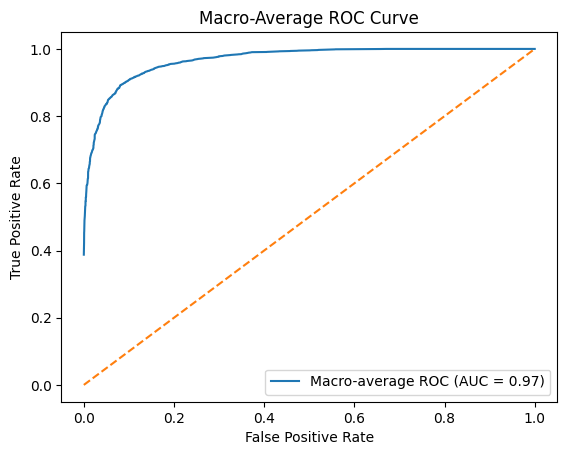

In [38]:
# MACRO ROC
all_fpr = np.unique(np.concatenate([
    roc_curve(y_true_bin[:, i], y_prob[:, i])[0]
    for i in range(num_classes)
]))

mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    mean_tpr += np.interp(all_fpr, fpr, tpr)

mean_tpr /= num_classes

roc_auc_macro = auc(all_fpr, mean_tpr)

plt.figure()
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {roc_auc_macro:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Macro-Average ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Time info

In [39]:
import time
start_time = time.time()
model, train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    DEVICE,
    EPOCHS
)
end_time = time.time()
training_time = end_time - start_time

print(f"Total Training Time: {training_time:.2f} seconds")
print(f"Total Training Time: {training_time/60:.2f} minutes")
print(f"Training Time: {training_time/3600:.2f} hours")

Epoch 1/100
Train Loss: 0.1987, Train Acc: 0.9263
Val Loss: 0.4509, Val Acc: 0.8653
----------------------------------------
Epoch 2/100
Train Loss: 0.1120, Train Acc: 0.9602
Val Loss: 0.4005, Val Acc: 0.8795
----------------------------------------
Epoch 3/100
Train Loss: 0.0822, Train Acc: 0.9680
Val Loss: 0.4011, Val Acc: 0.8877
----------------------------------------
Epoch 4/100
Train Loss: 0.0672, Train Acc: 0.9738
Val Loss: 0.5401, Val Acc: 0.8791
----------------------------------------
Epoch 5/100
Train Loss: 0.0686, Train Acc: 0.9711
Val Loss: 0.4475, Val Acc: 0.8912
----------------------------------------
Epoch 6/100
Train Loss: 0.0554, Train Acc: 0.9779
Val Loss: 0.5366, Val Acc: 0.8821
----------------------------------------
Epoch 7/100
Train Loss: 0.0484, Train Acc: 0.9796
Val Loss: 0.5493, Val Acc: 0.8886
----------------------------------------
Epoch 8/100
Train Loss: 0.0435, Train Acc: 0.9808
Val Loss: 0.5762, Val Acc: 0.8860
----------------------------------------


In [40]:
import os
from PIL import Image

base_path = "/kaggle/input/datasets/sumona2samia/skinburndataset/dataset_split/test/No Sunburn/normal_7da908e123b9da3711df_jpg.rf.1ff15d847cca77a7694aeb24428a7ce6.jpg"

# Find first image
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith((".jpg", ".png", ".jpeg")):
            img_path = os.path.join(root, file)
            break
    if 'img_path' in locals():
        break

print("Using image:", img_path)

image = Image.open(img_path).convert("RGB")

Using image: /kaggle/input/datasets/sumona2samia/skinburndataset/dataset_split/train/Second Degree Burn Partial of Intermediate Thickness/augmented_rotate_45_img987_jpg.rf.86db2ecf460a710ef29da7779bb3f2f8.jpg


In [41]:
import torch
from PIL import Image
import torchvision.transforms as transforms

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform (VERY IMPORTANT)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),   # 🔥 THIS fixes your error
])

# Load image
img_path = "/kaggle/input/datasets/sumona2samia/skinburndataset/dataset_split/test/No Sunburn/normal_7da908e123b9da3711df_jpg.rf.1ff15d847cca77a7694aeb24428a7ce6.jpg"
image = Image.open(img_path).convert("RGB")

# Apply transform
image = transform(image)        # PIL → Tensor
image = image.unsqueeze(0)      # Add batch dimension
image = image.to(device)

print(type(image))              # should be torch.Tensor
print(image.shape)              # [1, 3, 224, 224]

<class 'torch.Tensor'>
torch.Size([1, 3, 224, 224])


In [42]:
starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)

model.eval()

starter.record()

with torch.no_grad():
    output = model(image)

ender.record()

torch.cuda.synchronize()

inference_time = starter.elapsed_time(ender)  # ms

_, pred = torch.max(output, 1)
predicted_class = class_names[pred.item()]

print(f"Prediction: {predicted_class}")
print(f"Inference Time: {inference_time:.4f} ms")

Prediction: No Sunburn
Inference Time: 9.4007 ms


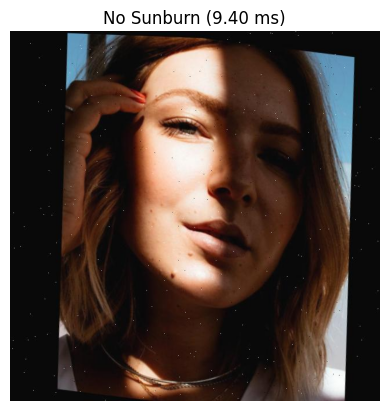

In [43]:
import matplotlib.pyplot as plt

plt.imshow(Image.open(img_path))
plt.title(f"{predicted_class} ({inference_time:.2f} ms)")
plt.axis("off")
plt.show()

Save & Load model

In [44]:
torch.save(model.state_dict(), "vgg19_weights.pth")

In [45]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": EPOCHS,
    "num_classes": num_classes
}, "checkpoint.pth")

In [46]:
from torchvision import models
import torch.nn as nn
import torch

model = models.vgg19(pretrained=False)
model.classifier[6] = nn.Linear(4096, num_classes)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [47]:
model.load_state_dict(torch.load("vgg19_weights.pth"))
model = model.to(DEVICE)
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [48]:
import os

print(os.path.exists("/kaggle/working/vgg19_best.pth"))

True


In [49]:
print(os.listdir("/kaggle/working"))

['checkpoint.pth', 'normalized_confusion_matrix.png', 'vgg19_best.pth', 'vgg19_weights.pth', '__notebook__.ipynb']


In [50]:
print(os.path.getsize("/kaggle/working/vgg19_best.pth"), "bytes")

558360693 bytes


In [51]:
model.load_state_dict(torch.load("/kaggle/working/vgg19_best.pth"))
print("Model loaded successfully ✅")

Model loaded successfully ✅


In [52]:
checkpoint = torch.load("/kaggle/working/checkpoint.pth")

print(checkpoint.keys())

dict_keys(['model_state_dict', 'optimizer_state_dict', 'epoch', 'num_classes'])


System Info

In [53]:
!pip install psutil

In [54]:
import torch
import psutil
import platform
import os

def print_system_info():

    print("===== SYSTEM INFO =====")

    # OS + Python
    print(f"OS: {platform.system()} {platform.release()}")
    print(f"Python Version: {platform.python_version()}")

    # CPU
    print(f"\nCPU: {platform.processor()}")
    print(f"CPU Cores: {psutil.cpu_count(logical=True)}")

    # RAM
    ram = psutil.virtual_memory()
    print(f"\nTotal RAM: {ram.total / (1024**3):.2f} GB")
    print(f"Available RAM: {ram.available / (1024**3):.2f} GB")
    print(f"Used RAM: {ram.used / (1024**3):.2f} GB")

    # Disk (ROM)
    disk = psutil.disk_usage('/')
    print(f"\nTotal Disk: {disk.total / (1024**3):.2f} GB")
    print(f"Used Disk: {disk.used / (1024**3):.2f} GB")
    print(f"Free Disk: {disk.free / (1024**3):.2f} GB")

    # GPU
    print("\n===== GPU INFO =====")
    if torch.cuda.is_available():
        print(f"GPU Name: {torch.cuda.get_device_name(0)}")
        print(f"GPU Count: {torch.cuda.device_count()}")

        props = torch.cuda.get_device_properties(0)
        print(f"Total GPU Memory: {props.total_memory / (1024**3):.2f} GB")

        print(f"Allocated GPU Memory: {torch.cuda.memory_allocated(0) / (1024**3):.2f} GB")
        print(f"Reserved GPU Memory: {torch.cuda.memory_reserved(0) / (1024**3):.2f} GB")
    else:
        print("No GPU available")

print_system_info()

===== SYSTEM INFO =====
OS: Linux 6.6.113+
Python Version: 3.12.12

CPU: x86_64
CPU Cores: 4

Total RAM: 31.35 GB
Available RAM: 28.96 GB
Used RAM: 1.79 GB

Total Disk: 8062.39 GB
Used Disk: 6842.42 GB
Free Disk: 1219.95 GB

===== GPU INFO =====
GPU Name: Tesla T4
GPU Count: 2
Total GPU Memory: 14.56 GB
Allocated GPU Memory: 3.94 GB
Reserved GPU Memory: 4.79 GB


In [55]:
if torch.cuda.is_available():
    print(f"GPU Memory Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
    print(f"GPU Memory Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")

GPU Memory Allocated: 4038.15 MB
GPU Memory Reserved: 4900.00 MB


In [56]:
torch.cuda.reset_peak_memory_stats()

# run training...

peak_mem = torch.cuda.max_memory_allocated() / (1024**3)
print(f"Peak GPU Memory Used: {peak_mem:.2f} GB")

Peak GPU Memory Used: 3.94 GB


In [57]:
print(f"CPU Usage: {psutil.cpu_percent()}%")

CPU Usage: 34.6%


In [58]:
starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)

model.eval()

starter.record()

with torch.no_grad():
    output = model(image)

ender.record()

torch.cuda.synchronize()

inference_time = starter.elapsed_time(ender)  # ms

_, pred = torch.max(output, 1)
predicted_class = class_names[pred.item()]

print(f"Prediction: {predicted_class}")
print(f"Inference Time: {inference_time:.4f} ms")

Prediction: No Sunburn
Inference Time: 17.1749 ms


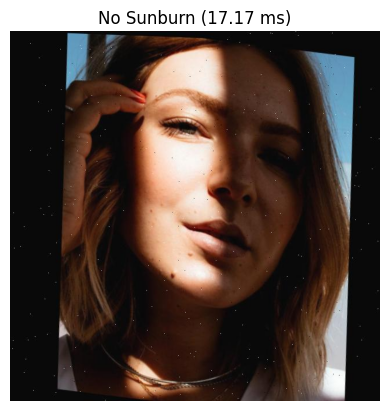

In [59]:
import matplotlib.pyplot as plt

plt.imshow(Image.open(img_path))
plt.title(f"{predicted_class} ({inference_time:.2f} ms)")
plt.axis("off")
plt.show()